## STEP 1: IMPORT LIBRARIES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

**Interpretation:**  
* pandas → used for data handling (EDA & cleaning)
* matplotlib → used for visualization (histogram/bar chart)

## STEP 2: LOAD THE DATASET

In [2]:
df = pd.read_csv('API_SP.POP.TOTL_DS2_en_csv_v2_38144.csv', skiprows=4)

**Interpretation:**
* We skip first 4 rows because they contain metadata (not actual data)
* Dataset contains:
    * Country names
    * Population data from 1960–2024

## STEP 3: BASIC EDA (EXPLORATORY DATA ANALYSIS)

### 3.1 Check structure of dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            264 non-null    float64
 5   1961            264 non-null    float64
 6   1962            264 non-null    float64
 7   1963            264 non-null    float64
 8   1964            264 non-null    float64
 9   1965            264 non-null    float64
 10  1966            264 non-null    float64
 11  1967            264 non-null    float64
 12  1968            264 non-null    float64
 13  1969            264 non-null    float64
 14  1970            264 non-null    float64
 15  1971            264 non-null    float64
 16  1972            264 non-null    float64
 17  1973            264 non-null    flo

**Interpretation:**
* Dataset has:
    * 266 rows (countries)
    * 70 columns (years + info columns)
* Most columns are numeric (population values)

### 3.2 Check missing values

In [4]:
df.isnull().sum()

Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960                2
                 ... 
2021                1
2022                1
2023                1
2024                1
Unnamed: 69       266
Length: 70, dtype: int64

**Interpretation:**
* Few missing values in some years
* One column (Unnamed: 69) is completely empty → useless

### 3.3 View sample data

In [5]:
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107624.0,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0,769294618.0,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN


**Interpretation:**
* Each row = one country
* Each column = population in a specific year

## STEP 4: DATA CLEANING

### 4.1 Remove useless columns

In [6]:
df = df.dropna(axis=1, how='all')

**Interpretation:**
* Removes columns with all missing values
* Improves dataset quality

### 4.2 Remove missing country names

In [7]:
df = df.dropna(subset=['Country Name'])

**Interpretation:**
* Ensures every row represents a valid country

### 4.3 Check cleaned data

In [8]:
df.shape

(266, 69)

In [11]:
df.isnull().sum().sum()

np.int64(95)

**Interpretation:**
* Confirms dataset is clean and ready for analysis

## STEP 5: SELECT A VARIABLE (CONTINUOUS VARIABLE)

In [12]:
data_2020 = df[['Country Name', '2020']].dropna()

**Interpretation:**
* We extract:
    * Country Name
    * Population in 2020
* Remove missing values for accurate plotting

## STEP 6: CREATE HISTOGRAM

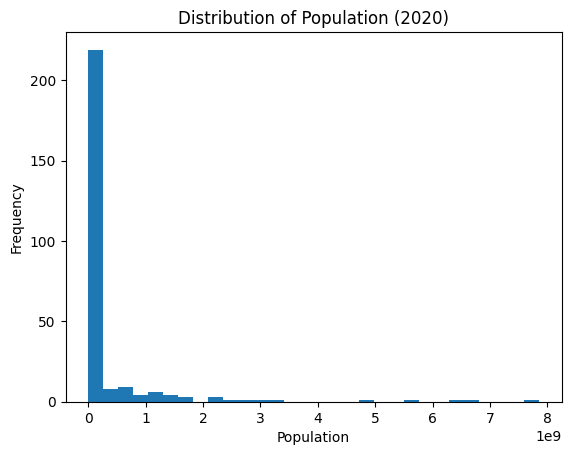

In [13]:
plt.figure()
plt.hist(data_2020['2020'], bins=30)
plt.title("Distribution of Population (2020)")
plt.xlabel("Population")
plt.ylabel("Frequency")
plt.show()

**Interpretation:**
* The graph shows distribution of population across countries
* Key observations:
    * Most countries have low population
    * Very few countries (like India, China) have extremely high population
    * This creates a right-skewed distribution
* Meaning:
    * Data is not evenly distributed
    * There are outliers (very large populations)

## STEP 7: BAR CHART FOR CATEGORICAL VARIABLE

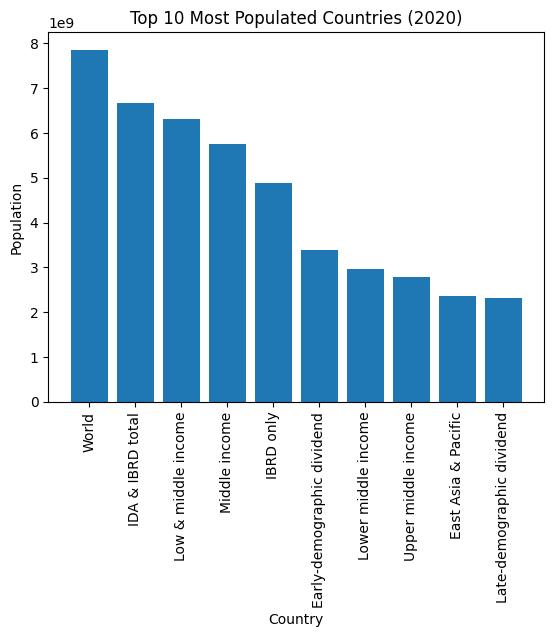

In [14]:
top10 = data_2020.sort_values(by='2020', ascending=False).head(10)

plt.figure()
plt.bar(top10['Country Name'], top10['2020'])
plt.xticks(rotation=90)
plt.title("Top 10 Most Populated Countries (2020)")
plt.xlabel("Country")
plt.ylabel("Population")
plt.show()

**Interpretation:**
* Top 10 most populated countries are selected
* Shows comparison between countries
* Easy to identify highest population countries